In [61]:
# --- cell 1: set up correct paths ---
from pathlib import Path

# start from current notebook folder
NOTEBOOK_DIR = Path.cwd()

# go one level up (to Project root)
PROJECT_ROOT = NOTEBOOK_DIR.parent
ROOT = PROJECT_ROOT / "data" / "runs" / "ca"

# NEW: figure output folder for Phase 1
FIGDIR = PROJECT_ROOT / "data" / "figures" / "phase1"
FIGDIR.mkdir(parents=True, exist_ok=True)

print("Notebook is here :", NOTEBOOK_DIR)
print("Project root     :", PROJECT_ROOT)
print("Data folder      :", ROOT)
print("Exists(data/runs/ca)?", ROOT.exists())


Notebook is here : c:\Users\John Koh\Desktop\Australia\University\2025 Sem 2\CITS 4403\Project\notebooks
Project root     : c:\Users\John Koh\Desktop\Australia\University\2025 Sem 2\CITS 4403\Project
Data folder      : c:\Users\John Koh\Desktop\Australia\University\2025 Sem 2\CITS 4403\Project\data\runs\ca
Exists(data/runs/ca)? True


In [63]:
# --- cell 2: common utils for all phases ---
from pathlib import Path
import json, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- low-level helpers ----------

def _num_to_pct(x):
    """Coerce '82.12%', 0.8212, or 82.12 to a % float in [0,100]."""
    if x is None:
        return None
    if isinstance(x, (int, float)):
        v = float(x)
    else:
        s = str(x).strip()
        if s.endswith("%"):
            try:
                v = float(s[:-1])
            except:
                return None
        else:
            try:
                v = float(s)
            except:
                return None
    if 0.0 <= v <= 1.0:  # treat as fraction
        v *= 100.0
    return v

def _try_extract_reach_from_json(js):
    """
    Try multiple key variants to find reachF / reachR inside a JSON object.
    Returns (reachF%, reachR%) or (None, None) if not found.
    """
    # Common variants
    candF = ["reachF","reach_f","fake_reach","reach_fake","ReachF","Reach_F"]
    candR = ["reachR","reach_r","real_reach","reach_real","ReachR","Reach_R"]
    rF = rR = None
    for k in candF:
        if k in js:
            rF = _num_to_pct(js[k]); break
    for k in candR:
        if k in js:
            rR = _num_to_pct(js[k]); break
    return rF, rR

def _load_summary_csv(batch_dir: Path) -> pd.DataFrame:
    """
    Load batch_dir/summary.csv if present. Normalise reach columns if they exist.
    Returns per-run DataFrame (can be 1 row summary or many runs).
    """
    csv_path = batch_dir / "summary.csv"
    if not csv_path.exists():
        return pd.DataFrame()
    df = pd.read_csv(csv_path)
    # strip % if present
    for col in ("reachF","reachR"):
        if col in df.columns:
            if df[col].dtype == object:
                df[col] = df[col].astype(str).str.replace("%","", regex=False)
            df[col] = pd.to_numeric(df[col], errors="coerce")
            # scale 0..1 to %
            if df[col].max() is not None and df[col].max() <= 1.0:
                df[col] = df[col] * 100.0
    return df

def _load_per_run_json_rows(batch_dir: Path) -> pd.DataFrame:
    """
    Scan *.json in the directory and pull per-run numbers if present.
    Returns DataFrame with columns among: reachF, reachR, peak_f, peak_r, t_peak_f, t_peak_r...
    """
    rows = []
    for jp in batch_dir.glob("*.json"):
        try:
            with open(jp, "r", encoding="utf-8") as f:
                data = json.load(f)
        except Exception:
            continue
        if isinstance(data, dict):
            row = {}
            # reach
            rF, rR = _try_extract_reach_from_json(data)
            row["reachF"] = rF
            row["reachR"] = rR
            # peak/time keys (tolerant)
            for k, aliases in {
                "peak_f": ["peak_f","peakF","peak_fake","fake_peak"],
                "peak_r": ["peak_r","peakR","peak_real","real_peak"],
                "t_peak_f": ["t_peak_f","tpeak_f","time_to_peak_f","tPeakF"],
                "t_peak_r": ["t_peak_r","tpeak_r","time_to_peak_r","tPeakR"],
            }.items():
                for a in aliases:
                    if a in data:
                        row[k] = data[a]; break
            # accept row if anything found
            if any(v is not None for v in row.values()):
                rows.append(row)
        elif isinstance(data, list):
            # list of per-run dicts
            for it in data:
                if not isinstance(it, dict):
                    continue
                row = {}
                rF, rR = _try_extract_reach_from_json(it)
                row["reachF"] = rF
                row["reachR"] = rR
                for k, aliases in {
                    "peak_f": ["peak_f","peakF","peak_fake","fake_peak"],
                    "peak_r": ["peak_r","peakR","peak_real","real_peak"],
                    "t_peak_f": ["t_peak_f","tpeak_f","time_to_peak_f","tPeakF"],
                    "t_peak_r": ["t_peak_r","tpeak_r","time_to_peak_r","tPeakR"],
                }.items():
                    for a in aliases:
                        if a in it:
                            row[k] = it[a]; break
                if any(v is not None for v in row.values()):
                    rows.append(row)
    if rows:
        df = pd.DataFrame(rows)
        # normalise reach %
        for col in ("reachF","reachR"):
            if col in df.columns:
                df[col] = df[col].map(_num_to_pct)
        return df
    return pd.DataFrame()

def load_batch_dataframe(batch_dir: Path) -> pd.DataFrame:
    """
    Load one batch dir, merging summary.csv (if present) with per-run JSON rows to fill missing metrics.
    """
    df_csv = _load_summary_csv(batch_dir)
    df_js  = _load_per_run_json_rows(batch_dir)
    if df_csv.empty and df_js.empty:
        return pd.DataFrame()
    if df_csv.empty:
        return df_js
    if df_js.empty:
        return df_csv
    # merge by position (pad to same length)
    n = max(len(df_csv), len(df_js))
    def _pad(df):
        if len(df) == n: return df.reset_index(drop=True)
        if len(df) == 0: return pd.DataFrame(index=range(n))
        reps = int(np.ceil(n/len(df)))
        out = pd.concat([df]*reps, ignore_index=True).iloc[:n]
        return out.reset_index(drop=True)

    a = _pad(df_csv)
    b = _pad(df_js)
    # prefer values from CSV; fill NaNs from JSON
    merged = a.copy()
    for col in set(b.columns) - set(a.columns):
        merged[col] = np.nan
    for col in b.columns:
        merged[col] = np.where(merged[col].isna(), b[col], merged[col])
    return merged

def summarise_condition(batch_dirs: list[Path]) -> pd.Series:
    """
    Concatenate per-run rows from all batch dirs, compute mean/std/n for key metrics.
    """
    dfs = []
    for d in batch_dirs:
        df = load_batch_dataframe(d)
        if not df.empty:
            dfs.append(df)
    if not dfs:
        return pd.Series(dtype=float)
    df = pd.concat(dfs, ignore_index=True)

    # keep known columns if present
    wanted = ["reachF","reachR","peak_f","peak_r","t_peak_f","t_peak_r"]
    cols = [c for c in wanted if c in df.columns]
    if not cols:
        return pd.Series(dtype=float)
    df = df[cols].copy()

    # normalise reach
    for col in ("reachF","reachR"):
        if col in df.columns:
            df[col] = df[col].map(_num_to_pct)

    out = {}
    for col in cols:
        ser = pd.to_numeric(df[col], errors="coerce")
        out[f"mean_{col}"] = ser.mean()
        out[f"std_{col}"]  = ser.std(ddof=1)
        out[f"n_{col}"]    = ser.notna().sum()
    return pd.Series(out)

def find_dirs_by_prefix(root: Path, prefix: str) -> list[Path]:
    return sorted([p for p in root.iterdir() if p.is_dir() and p.name.startswith(prefix)])

def find_dirs_by_contains(root: Path, contains: str) -> list[Path]:
    return sorted([p for p in root.iterdir() if p.is_dir() and contains in p.name])

# ---------- plotting helpers (single-figure each) ----------

def plot_grouped_reach(df, label_col, figpath, title):
    labels = df[label_col].tolist()
    x = np.arange(len(labels))
    w = 0.38

    yF = df["mean_reachF"].to_numpy()
    eF = df["std_reachF"].to_numpy()
    yR = df["mean_reachR"].to_numpy()
    eR = df["std_reachR"].to_numpy()

    fig, ax = plt.subplots(figsize=(11,6))
    ax.bar(x - w/2, yF, width=w, yerr=eF, capsize=3, label="Fake Reach (%)")
    ax.bar(x + w/2, yR, width=w, yerr=eR, capsize=3, label="Real Reach (%)")
    ax.set_ylabel("Reach (%)")
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_ylim(0, 105)
    ax.grid(axis="y", alpha=0.25)
    ax.legend(loc="upper left")
    plt.tight_layout()
    fig.savefig(figpath, dpi=200)
    plt.show()

def plot_time_to_peak(df, label_col, figpath, title):
    labels = df[label_col].tolist()
    x = np.arange(len(labels))
    tpf = df["mean_t_peak_f"].to_numpy()
    tpr = df["mean_t_peak_r"].to_numpy()
    ef  = df["std_t_peak_f"].to_numpy()
    er  = df["std_t_peak_r"].to_numpy()

    fig, ax = plt.subplots(figsize=(11,6))
    ax.errorbar(x, tpf, yerr=ef, marker="o", linewidth=2, label="t_peak_f")
    ax.errorbar(x, tpr, yerr=er, marker="s", linewidth=2, label="t_peak_r")
    ax.set_title(title)
    ax.set_ylabel("Time steps")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    fig.savefig(figpath, dpi=200)
    plt.show()

def plot_peak_bars(df, label_col, figpath, title):
    labels = df[label_col].tolist()
    x = np.arange(len(labels))
    w = 0.38
    pf = df["mean_peak_f"].to_numpy()
    pr = df["mean_peak_r"].to_numpy()
    sf = df["std_peak_f"].to_numpy()
    sr = df["std_peak_r"].to_numpy()

    fig, ax = plt.subplots(figsize=(11,6))
    ax.bar(x - w/2, pf, width=w, yerr=sf, capsize=3, label="Peak Fake (posters)")
    ax.bar(x + w/2, pr, width=w, yerr=sr, capsize=3, label="Peak Real (posters)")
    ax.set_title(title)
    ax.set_ylabel("Number of posters at peak")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.grid(axis="y", alpha=0.25)
    ax.legend()
    plt.tight_layout()
    fig.savefig(figpath, dpi=200)
    plt.show()

def plot_scatter_peak_vs_reach_fake(df, label_col, figpath, title):
    labels = df[label_col].tolist()
    pf = df["mean_peak_f"].to_numpy()
    rf = df["mean_reachF"].to_numpy()
    sf_pf = df["std_peak_f"].to_numpy()
    sf_rf = df["std_reachF"].to_numpy()

    fig, ax = plt.subplots(figsize=(9,7))
    ax.errorbar(pf, rf, xerr=sf_pf, yerr=sf_rf, fmt="o", ms=8, capsize=3)
    for x,y,name in zip(pf, rf, labels):
        ax.annotate(name, (x,y), xytext=(5,5), textcoords="offset points", fontsize=9)
    ax.set_xlabel("Peak Fake (posters)")
    ax.set_ylabel("Fake Reach (%)")
    ax.set_title(title)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    fig.savefig(figpath, dpi=200)
    plt.show()


Saved Excel → c:\Users\John Koh\Desktop\Australia\University\2025 Sem 2\CITS 4403\Project\data\figures\phase1\phase1_metrics.xlsx


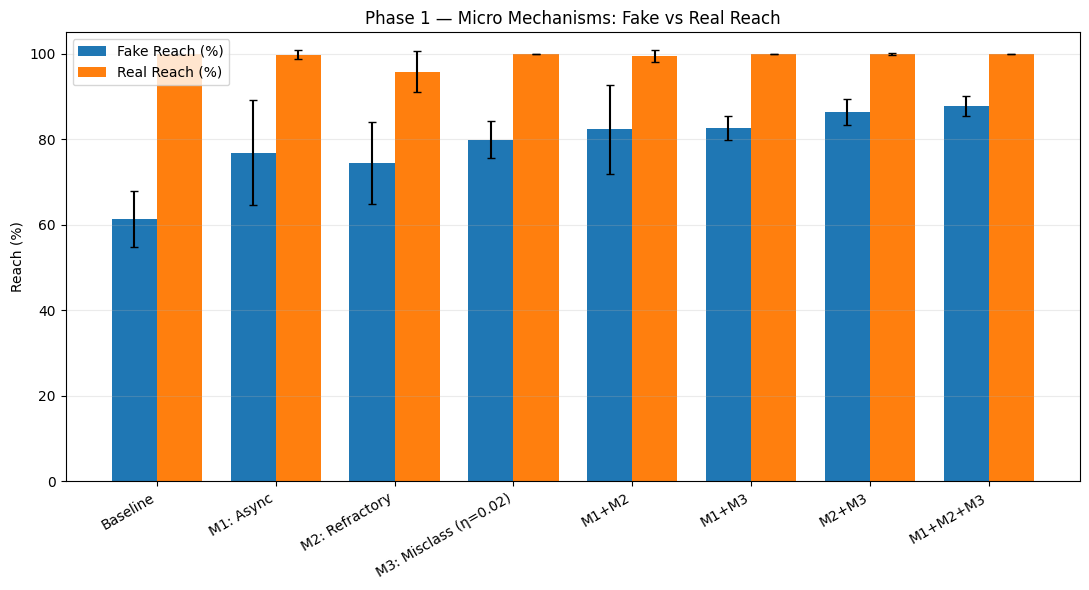

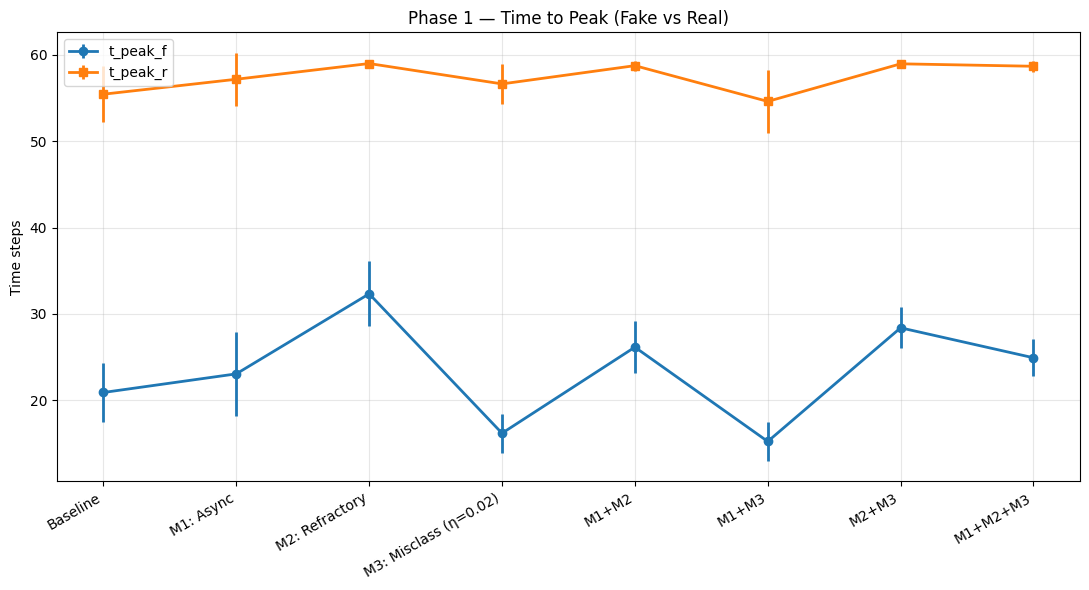

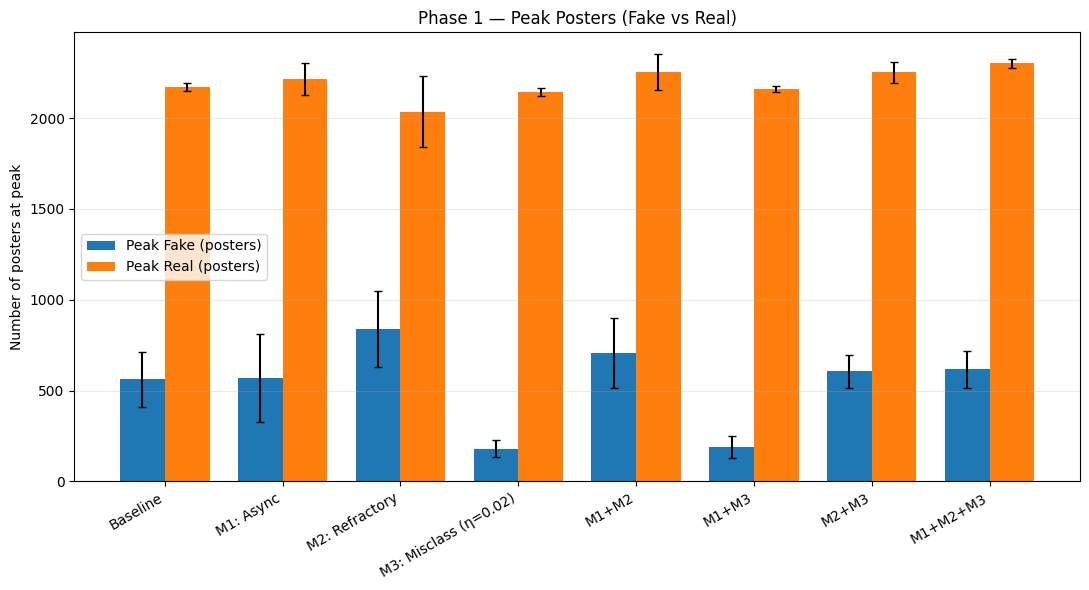

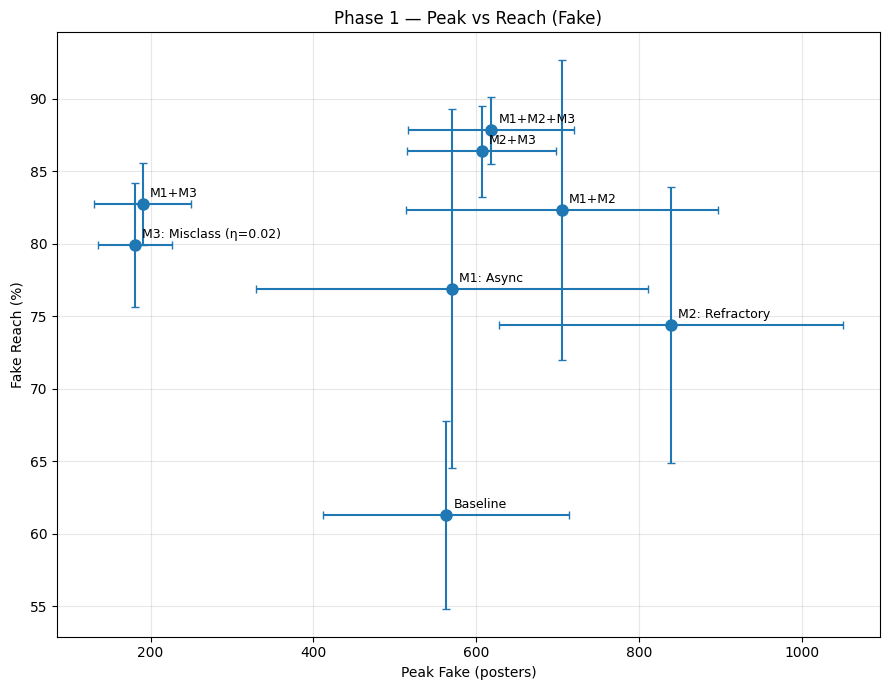

In [65]:
# --- cell 3: PHASE 1 aggregation + outputs ---
FIGDIR = PROJECT_ROOT / "data" / "figures" / "phase1"
FIGDIR.mkdir(parents=True, exist_ok=True)

# mapping prefixes to pretty labels in desired order
P1 = [
    ("baseline_", "Baseline"),
    ("async_", "M1: Async"),
    ("refractory_", "M2: Refractory"),
    ("misclass_", "M3: Misclass (η=0.02)"),
    ("async_refractory_", "M1+M2"),
    ("async_misclass_", "M1+M3"),
    ("refractory_misclass_", "M2+M3"),
    ("async_refractory_misclass_", "M1+M2+M3"),
]

rows = []
for prefix, label in P1:
    dirs = find_dirs_by_prefix(ROOT, prefix)
    stats = summarise_condition(dirs)
    if stats.empty:
        continue
    stats["Condition"] = label
    rows.append(stats)

phase1_df = pd.DataFrame(rows)
if phase1_df.empty:
    raise RuntimeError("No Phase 1 batches found. Check your folder names.")

# order by our list
order_map = {label:i for i,(_,label) in enumerate(P1)}
phase1_df["__o"] = phase1_df["Condition"].map(order_map).fillna(999)
phase1_df = phase1_df.sort_values("__o").drop(columns="__o")

# save Excel
excel_path = FIGDIR / "phase1_metrics.xlsx"
with pd.ExcelWriter(excel_path, engine="xlsxwriter") as xw:
    phase1_df.set_index("Condition").round(3).to_excel(xw, sheet_name="Phase1_Summary")
print(f"Saved Excel → {excel_path}")

# plot 1: grouped reach
if {"mean_reachF","std_reachF","mean_reachR","std_reachR"}.issubset(phase1_df.columns):
    plot_grouped_reach(
        phase1_df, "Condition", FIGDIR/"phase1_plot1_reach_grouped.png",
        "Phase 1 — Micro Mechanisms: Fake vs Real Reach"
    )
else:
    print("⚠️ Reach columns missing; skipping Plot 1 for Phase 1 (grouped reach).")

# plot 2: time to peak
if {"mean_t_peak_f","std_t_peak_f","mean_t_peak_r","std_t_peak_r"}.issubset(phase1_df.columns):
    plot_time_to_peak(
        phase1_df, "Condition", FIGDIR/"phase1_plot2_time_to_peak.png",
        "Phase 1 — Time to Peak (Fake vs Real)"
    )
else:
    print("⚠️ Time-to-peak columns missing; skipping Plot 2 for Phase 1.")

# plot 3: peaks
if {"mean_peak_f","std_peak_f","mean_peak_r","std_peak_r"}.issubset(phase1_df.columns):
    plot_peak_bars(
        phase1_df, "Condition", FIGDIR/"phase1_plot3_peak_posters.png",
        "Phase 1 — Peak Posters (Fake vs Real)"
    )
else:
    print("⚠️ Peak columns missing; skipping Plot 3 for Phase 1.")

# plot 4: scatter peak vs reach (fake)
if {"mean_peak_f","std_peak_f","mean_reachF","std_reachF"}.issubset(phase1_df.columns):
    plot_scatter_peak_vs_reach_fake(
        phase1_df, "Condition", FIGDIR/"phase1_plot4_scatter_peak_vs_reach_fake.png",
        "Phase 1 — Peak vs Reach (Fake)"
    )
else:
    print("⚠️ Need peak_f and reachF to draw Plot 4; skipping for Phase 1.")


Saved Excel → c:\Users\John Koh\Desktop\Australia\University\2025 Sem 2\CITS 4403\Project\data\figures\phase2\phase2_metrics.xlsx


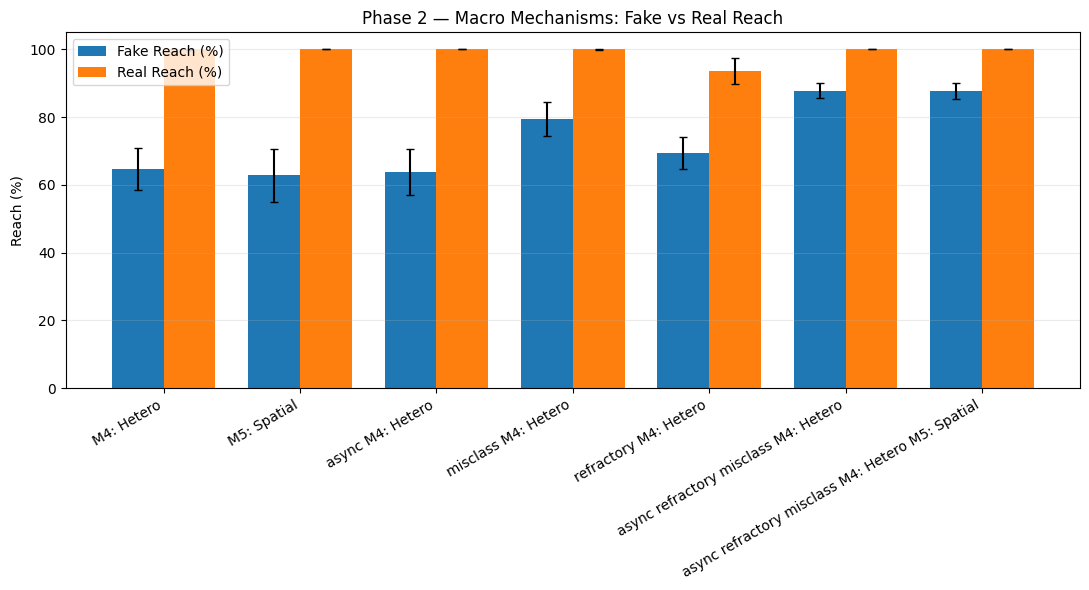

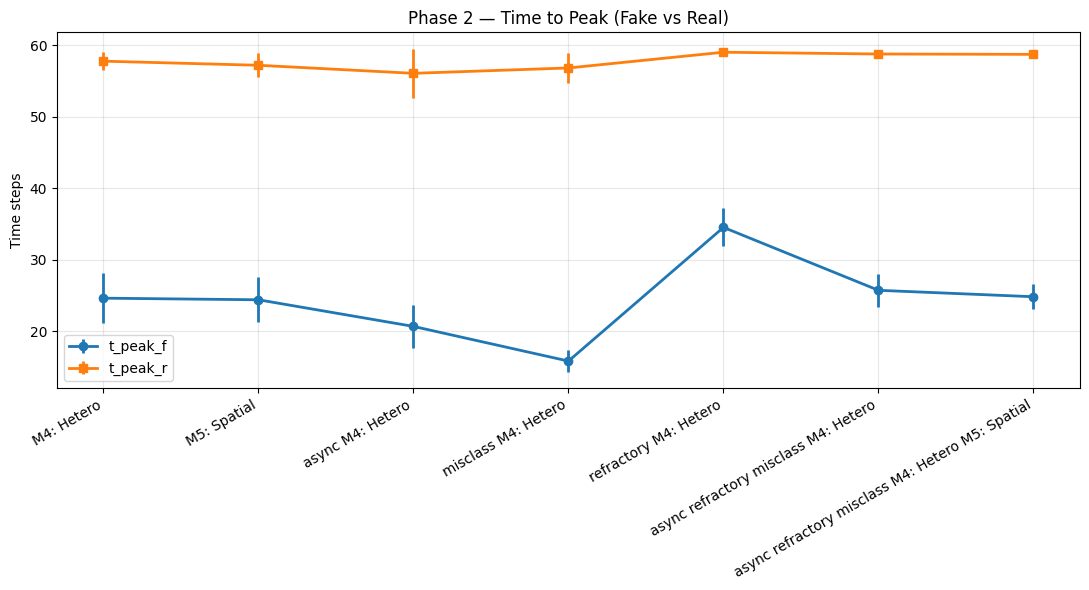

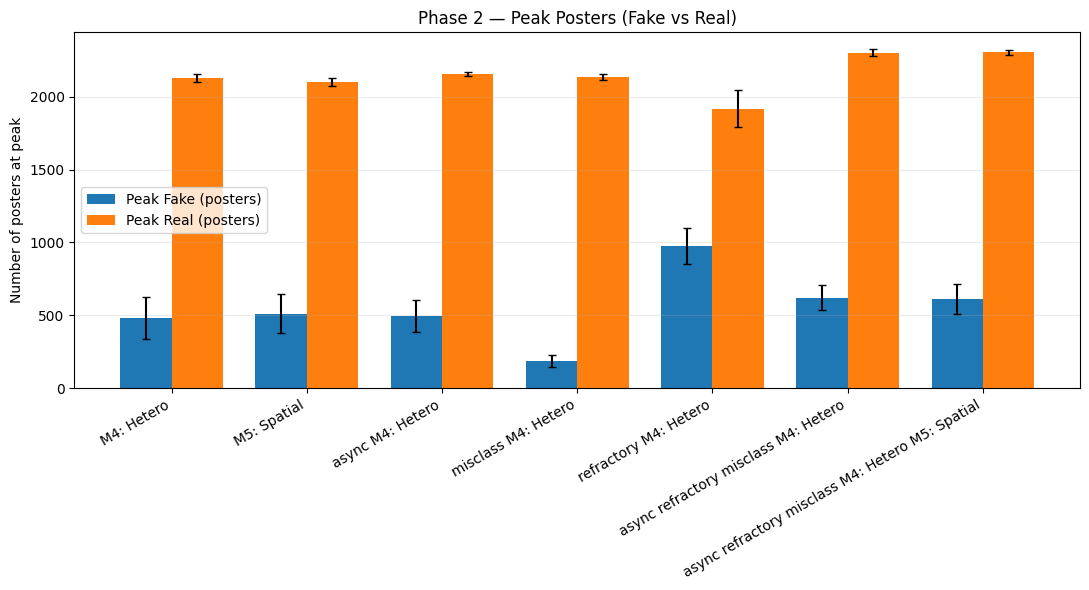

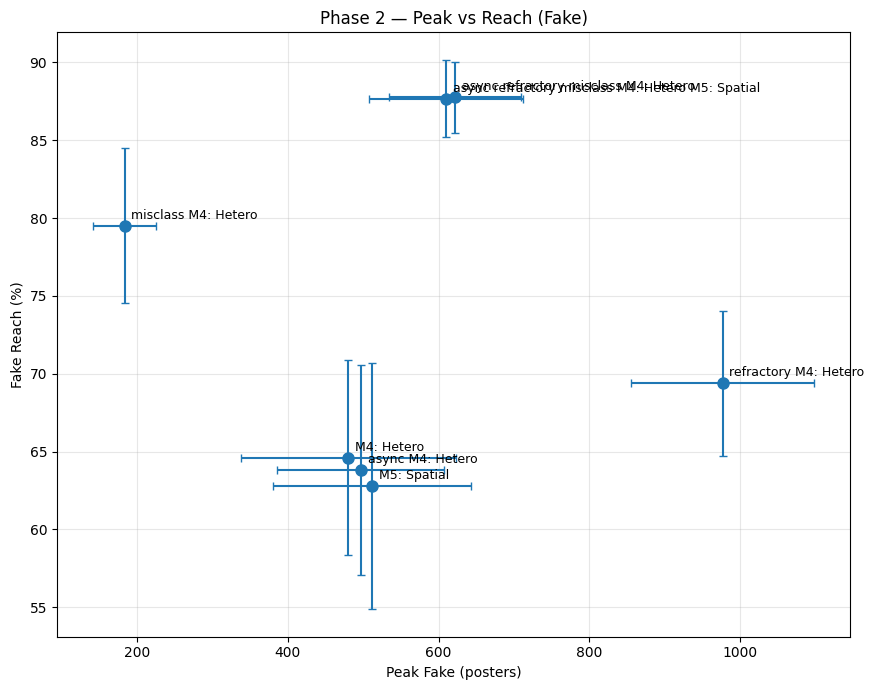

In [66]:
# --- cell 4: PHASE 2 aggregation + outputs (heterogeneity, spatial if present) ---
FIGDIR2 = PROJECT_ROOT / "data" / "figures" / "phase2"
FIGDIR2.mkdir(parents=True, exist_ok=True)

# We consider any batch directory that contains 'hetero' or 'spatial' as Phase 2 macro variants
# Provide a stable display label:
def label_phase2(dir_name: str) -> str:
    lbl = dir_name
    # common mappings for nicer labels
    lbl = lbl.replace("hetero", "M4: Hetero")
    lbl = lbl.replace("spatial", "M5: Spatial")
    lbl = lbl.replace("_", " ").strip()
    # compress leading CA_ if present
    lbl = re.sub(r"^\s*CA\s*", "", lbl, flags=re.IGNORECASE)
    # shorten long timestamps
    lbl = re.sub(r"\d{8}-\d{6}$", "", lbl).strip()
    return lbl

macro_dirs = [p for p in ROOT.iterdir() if p.is_dir() and ("hetero" in p.name or "spatial" in p.name)]

# group by mechanism signature (strip timestamps)
def mech_key(p: Path) -> str:
    return re.sub(r"_\d{8}-\d{6}$","", p.name)

groups = {}
for d in macro_dirs:
    groups.setdefault(mech_key(d), []).append(d)

rows2 = []
for key, dirs in sorted(groups.items()):
    stats = summarise_condition(dirs)
    if stats.empty:
        continue
    stats["Condition"] = label_phase2(key)
    rows2.append(stats)

phase2_df = pd.DataFrame(rows2)
if phase2_df.empty:
    print("⚠️ No Phase 2 macro batches found (hetero/spatial). If you do have them, check folder names.")
else:
    # Sort alphabetically but put simpler configs first by length
    phase2_df["__o"] = phase2_df["Condition"].apply(len)
    phase2_df = phase2_df.sort_values(["__o","Condition"]).drop(columns="__o")

    # Excel
    excel2 = FIGDIR2 / "phase2_metrics.xlsx"
    with pd.ExcelWriter(excel2, engine="xlsxwriter") as xw:
        phase2_df.set_index("Condition").round(3).to_excel(xw, sheet_name="Phase2_Summary")
    print(f"Saved Excel → {excel2}")

    # Plots (same 4 types)
    if {"mean_reachF","std_reachF","mean_reachR","std_reachR"}.issubset(phase2_df.columns):
        plot_grouped_reach(
            phase2_df, "Condition", FIGDIR2/"phase2_plot1_reach_grouped.png",
            "Phase 2 — Macro Mechanisms: Fake vs Real Reach"
        )
    else:
        print("⚠️ Reach columns missing; skipping Plot 1 for Phase 2.")

    if {"mean_t_peak_f","std_t_peak_f","mean_t_peak_r","std_t_peak_r"}.issubset(phase2_df.columns):
        plot_time_to_peak(
            phase2_df, "Condition", FIGDIR2/"phase2_plot2_time_to_peak.png",
            "Phase 2 — Time to Peak (Fake vs Real)"
        )
    else:
        print("⚠️ Time-to-peak columns missing; skipping Plot 2 for Phase 2.")

    if {"mean_peak_f","std_peak_f","mean_peak_r","std_peak_r"}.issubset(phase2_df.columns):
        plot_peak_bars(
            phase2_df, "Condition", FIGDIR2/"phase2_plot3_peak_posters.png",
            "Phase 2 — Peak Posters (Fake vs Real)"
        )
    else:
        print("⚠️ Peak columns missing; skipping Plot 3 for Phase 2.")

    if {"mean_peak_f","std_peak_f","mean_reachF","std_reachF"}.issubset(phase2_df.columns):
        plot_scatter_peak_vs_reach_fake(
            phase2_df, "Condition", FIGDIR2/"phase2_plot4_scatter_peak_vs_reach_fake.png",
            "Phase 2 — Peak vs Reach (Fake)"
        )
    else:
        print("⚠️ Need peak_f and reachF to draw Plot 4; skipping for Phase 2.")



Saved Excel → c:\Users\John Koh\Desktop\Australia\University\2025 Sem 2\CITS 4403\Project\data\figures\phase3\phase3_metrics.xlsx


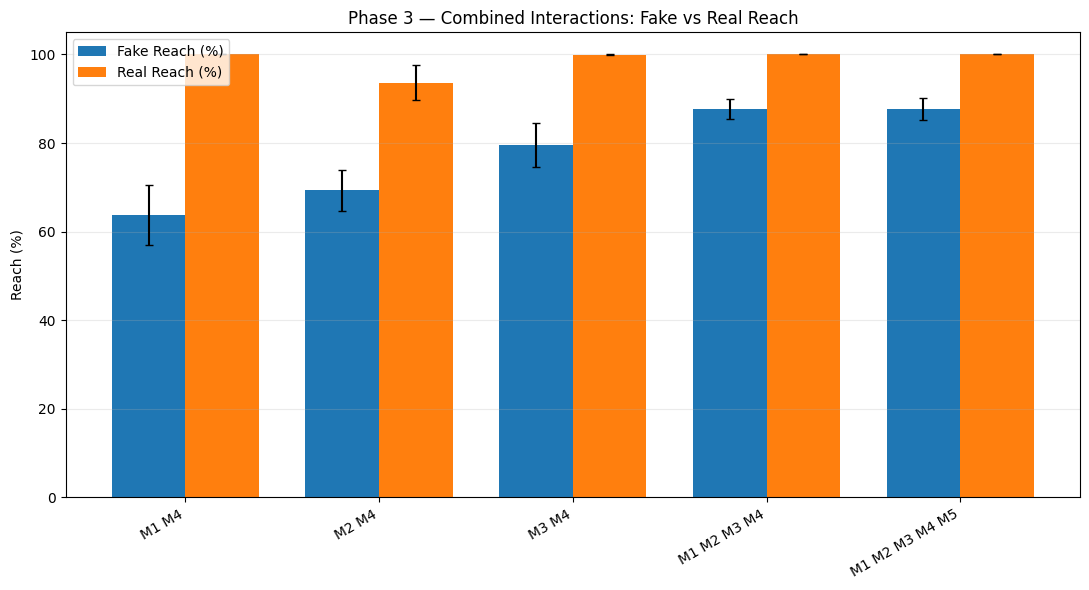

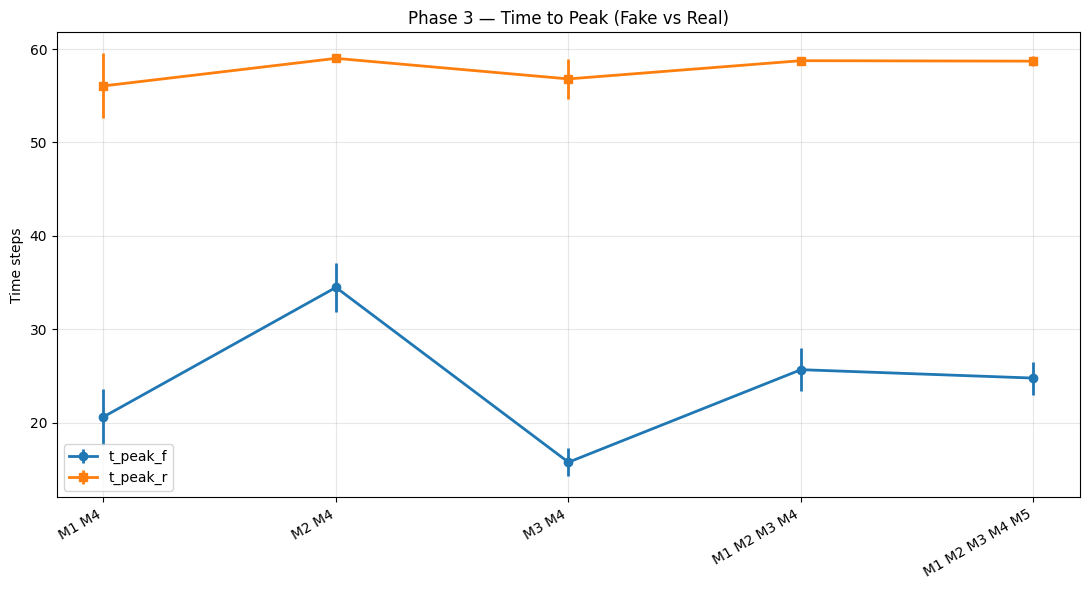

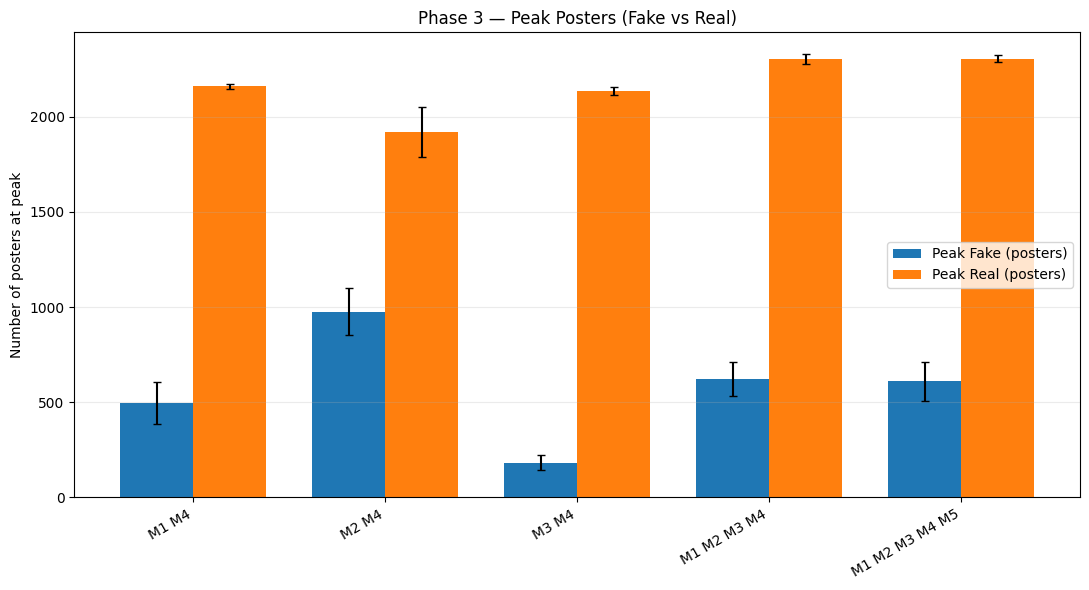

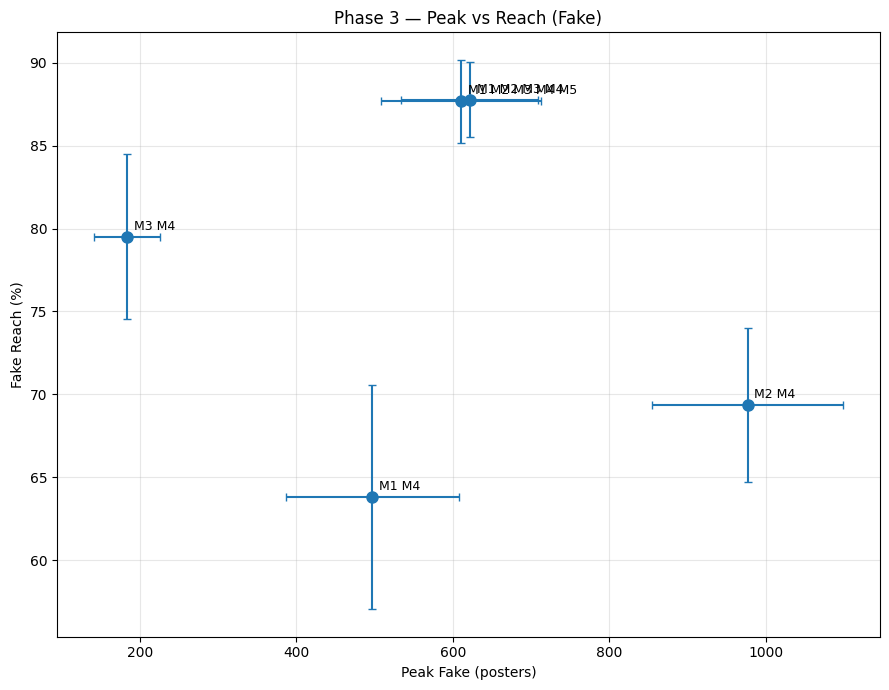

In [67]:
# --- cell 5: PHASE 3 aggregation + outputs (combined micro+macro interactions) ---
FIGDIR3 = PROJECT_ROOT / "data" / "figures" / "phase3"
FIGDIR3.mkdir(parents=True, exist_ok=True)

# Heuristic: Phase 3 are the more complex combos: contain both (at least one micro from phase1)
# and a macro keyword (hetero/spatial). We'll detect dirs that include either 'hetero' or 'spatial'
# and ALSO include one of ['async','refractory','misclass'].

MICRO_TOKENS = ("async","refractory","misclass")
MACRO_TOKENS = ("hetero","spatial")

phase3_dirs = []
for p in ROOT.iterdir():
    if not p.is_dir(): 
        continue
    name = p.name
    if any(m in name for m in MACRO_TOKENS) and any(s in name for s in MICRO_TOKENS):
        phase3_dirs.append(p)

# group by mechanism signature (strip timestamps)
def mech_key3(p: Path) -> str:
    return re.sub(r"_\d{8}-\d{6}$","", p.name)

groups3 = {}
for d in phase3_dirs:
    groups3.setdefault(mech_key3(d), []).append(d)

def nice_label3(key: str) -> str:
    s = key
    s = s.replace("async", "M1")
    s = s.replace("refractory", "M2")
    s = s.replace("misclass", "M3")
    s = s.replace("hetero", "M4")
    s = s.replace("spatial", "M5")
    s = s.replace("_", " ")
    s = re.sub(r"\s+", " ", s).strip()
    return s

rows3 = []
for key, dirs in sorted(groups3.items()):
    stats = summarise_condition(dirs)
    if stats.empty:
        continue
    stats["Condition"] = nice_label3(key)
    rows3.append(stats)

phase3_df = pd.DataFrame(rows3)
if phase3_df.empty:
    print("⚠️ No Phase 3 interaction batches found. Run combined micro+macro configs first.")
else:
    # sort by number of mechanisms then by name
    phase3_df["__k"] = phase3_df["Condition"].apply(lambda s: len(s.split()))
    phase3_df = phase3_df.sort_values(["__k","Condition"]).drop(columns="__k")

    # Excel
    excel3 = FIGDIR3 / "phase3_metrics.xlsx"
    with pd.ExcelWriter(excel3, engine="xlsxwriter") as xw:
        phase3_df.set_index("Condition").round(3).to_excel(xw, sheet_name="Phase3_Summary")
    print(f"Saved Excel → {excel3}")

    # Plots
    if {"mean_reachF","std_reachF","mean_reachR","std_reachR"}.issubset(phase3_df.columns):
        plot_grouped_reach(
            phase3_df, "Condition", FIGDIR3/"phase3_plot1_reach_grouped.png",
            "Phase 3 — Combined Interactions: Fake vs Real Reach"
        )
    else:
        print("⚠️ Reach columns missing; skipping Plot 1 for Phase 3.")

    if {"mean_t_peak_f","std_t_peak_f","mean_t_peak_r","std_t_peak_r"}.issubset(phase3_df.columns):
        plot_time_to_peak(
            phase3_df, "Condition", FIGDIR3/"phase3_plot2_time_to_peak.png",
            "Phase 3 — Time to Peak (Fake vs Real)"
        )
    else:
        print("⚠️ Time-to-peak columns missing; skipping Plot 2 for Phase 3.")

    if {"mean_peak_f","std_peak_f","mean_peak_r","std_peak_r"}.issubset(phase3_df.columns):
        plot_peak_bars(
            phase3_df, "Condition", FIGDIR3/"phase3_plot3_peak_posters.png",
            "Phase 3 — Peak Posters (Fake vs Real)"
        )
    else:
        print("⚠️ Peak columns missing; skipping Plot 3 for Phase 3.")

    if {"mean_peak_f","std_peak_f","mean_reachF","std_reachF"}.issubset(phase3_df.columns):
        plot_scatter_peak_vs_reach_fake(
            phase3_df, "Condition", FIGDIR3/"phase3_plot4_scatter_peak_vs_reach_fake.png",
            "Phase 3 — Peak vs Reach (Fake)"
        )
    else:
        print("⚠️ Need peak_f and reachF to draw Plot 4; skipping for Phase 3.")
